# 06 · Our Own Mini-Framework: everything so far as reusable classes
NumPy only · Runs on Google Colab

1. Why classes?
2. `Layer` and `Dense` (threshold ➜ bias)
3. Activations and Dropout as layers
4. Losses as classes
5. Optimisers as classes
6. `Sequential`: `fit`, `predict`, `evaluate`, `summary`
7. A nudge check that works for any network
8. Using it: XOR data, spirals, digits, MNIST, car fuel efficiency
9. Adding something new: one small class
10. Our classes vs Keras vs PyTorch

---
# Part 1: why classes?
So far every new idea (an activation, an optimiser, dropout, a loss) meant **editing** `forward_pass` / `backward_pass` / `train`.
With classes, each idea is **one small piece** with the same two methods, and the pieces snap together:

| Piece | Has | Must provide |
|---|---|---|
| layer | its own weights (if any) | `forward(X)`, `backward(grad)` |
| loss | — | `forward(output, y)`, `backward()` |
| optimiser | its own memory (momentum, …) | `step(layers)` |
| model | a list of layers + a loss + an optimiser | `fit`, `predict`, `evaluate` |

---
# Part 2: `Layer` and `Dense`
From here on we write the threshold as a **bias** $b$, like every framework does: $x \cdot w - w_0 = x \cdot w + b$ with $b = -w_0$. Same thing, different sign.

In [1]:
import io, time, urllib.request
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
np.set_printoptions(precision=4, suppress=True)
np.seterr(all="ignore")

x = np.array([0.5, -1.2])
w, w0 = np.array([0.8, 0.3]), 0.4
print(f"threshold form: x·w - w0 = {x @ w - w0:.4f} | bias form: x·w + b with b = -w0 = {x @ w + (-w0):.4f}")

threshold form: x·w - w0 = -0.3600 | bias form: x·w + b with b = -w0 = -0.3600


In [2]:
class Layer:
    # every layer: forward(X, training) -> output, backward(grad of output) -> grad of input
    def params_and_grads(self):
        return []                                                 # layers without weights have nothing to update

class Dense(Layer):
    def __init__(self, n_in, n_out, init="he", l2=0.0):
        spread = np.sqrt((2 if init == "he" else 1) / n_in)        # He for ReLU, Xavier for tanh/sigmoid
        self.W = rng.normal(0, spread, (n_in, n_out))
        self.b = np.zeros(n_out)
        self.l2 = l2

    def forward(self, X, training=False):
        self.X = X
        return X @ self.W + self.b

    def backward(self, grad):
        self.dW = self.X.T @ grad + 2 * self.l2 * self.W           # slope of the loss (+ L2 shrink)
        self.db = grad.sum(axis=0)
        return grad @ self.W.T                                    # error passed back to the previous layer

    def params_and_grads(self):
        return [(self.W, self.dW), (self.b, self.db)]

---
# Part 3: activations and dropout as layers (no weights, just forward and slope)

In [3]:
class ReLU(Layer):
    def forward(self, X, training=False):
        self.S = X
        return np.maximum(0, X)
    def backward(self, grad):
        return grad * (self.S > 0)

class Tanh(Layer):
    def forward(self, X, training=False):
        self.out = np.tanh(X)
        return self.out
    def backward(self, grad):
        return grad * (1 - self.out ** 2)

class Sigmoid(Layer):
    def forward(self, X, training=False):
        self.out = 1 / (1 + np.exp(-X))
        return self.out
    def backward(self, grad):
        return grad * self.out * (1 - self.out)

class Dropout(Layer):
    def __init__(self, p):
        self.p = p
    def forward(self, X, training=False):
        self.mask = (rng.random(X.shape) >= self.p) / (1 - self.p) if training else np.ones_like(X)
        return X * self.mask                                      # switched off only while training
    def backward(self, grad):
        return grad * self.mask

---
# Part 4: losses as classes
Each loss also knows how to turn the raw output into a prediction (`output`), and what kind of problem it is for (`task`). The output layer has **no activation**: softmax / sigmoid live inside the loss (simpler slope: $p - y$).

In [4]:
class SoftmaxCrossEntropy:
    task = "multiclass"
    def __init__(self, label_smoothing=0.0):
        self.eps = label_smoothing
    def output(self, S):
        E = np.exp(S - S.max(axis=1, keepdims=True))
        return E / E.sum(axis=1, keepdims=True)
    def forward(self, S, y):
        self.P = self.output(S)
        K = S.shape[1]
        self.Y = np.eye(K)[y] * (1 - self.eps) + self.eps / K
        return -np.mean(np.sum(self.Y * np.log(self.P + 1e-12), axis=1))
    def backward(self):
        return (self.P - self.Y) / len(self.P)                    # p - y, averaged over the batch

class BinaryCrossEntropy:
    task = "binary"
    def output(self, S):
        return 1 / (1 + np.exp(-S))
    def forward(self, S, y):
        self.P, self.Y = self.output(S), y.reshape(S.shape)
        return -np.mean(self.Y * np.log(self.P + 1e-12) + (1 - self.Y) * np.log(1 - self.P + 1e-12))
    def backward(self):
        return (self.P - self.Y) / len(self.P)

class MSE:
    task = "regression"
    def output(self, S):
        return S
    def forward(self, S, y):
        self.E = S - y.reshape(S.shape)
        return np.mean(self.E ** 2)
    def backward(self):
        return 2 * self.E / self.E.size

class Huber:
    task = "regression"
    def __init__(self, delta=1.0):
        self.delta = delta
    def output(self, S):
        return S
    def forward(self, S, y):
        self.E = S - y.reshape(S.shape)
        a = np.abs(self.E)
        return np.mean(np.where(a <= self.delta, 0.5 * self.E ** 2, self.delta * (a - 0.5 * self.delta)))
    def backward(self):
        return np.clip(self.E, -self.delta, self.delta) / self.E.size

---
# Part 5: optimisers as classes (each keeps its own memory per weight)

In [5]:
class SGD:
    def __init__(self, lr=0.01):
        self.lr = lr
    def step(self, layers):
        for layer in layers:
            for p, g in layer.params_and_grads():
                p -= self.lr * g                                  # update in place

class Momentum:
    def __init__(self, lr=0.01, beta=0.9):
        self.lr, self.beta, self.v = lr, beta, {}
    def step(self, layers):
        for layer in layers:
            for p, g in layer.params_and_grads():
                v = self.v.setdefault(id(p), np.zeros_like(p))
                v *= self.beta
                v -= self.lr * g
                p += v

class Adam:
    def __init__(self, lr=0.001):
        self.lr, self.t, self.m, self.s = lr, 0, {}, {}
    def step(self, layers):
        self.t += 1
        for layer in layers:
            for p, g in layer.params_and_grads():
                m = self.m.setdefault(id(p), np.zeros_like(p))
                s = self.s.setdefault(id(p), np.zeros_like(p))
                m[:] = 0.9 * m + 0.1 * g
                s[:] = 0.999 * s + 0.001 * g ** 2
                p -= self.lr * (m / (1 - 0.9 ** self.t)) / (np.sqrt(s / (1 - 0.999 ** self.t)) + 1e-8)

---
# Part 6: `Sequential`
The same loop as always (forward ➜ loss ➜ backward ➜ update), now written once for every network.

In [6]:
class Sequential:
    def __init__(self, layers):
        self.layers = layers

    def compile(self, loss, optimizer):
        self.loss, self.optimizer = loss, optimizer

    def forward(self, X, training=False):
        for layer in self.layers:
            X = layer.forward(X, training)
        return X

    def backward(self, grad):
        for layer in reversed(self.layers):
            grad = layer.backward(grad)

    def predict(self, X):
        out = self.loss.output(self.forward(X))
        if self.loss.task == "multiclass":
            return out.argmax(axis=1)
        return (out[:, 0] > 0.5).astype(int) if self.loss.task == "binary" else out[:, 0]

    def evaluate(self, X, y):
        loss = self.loss.forward(self.forward(X), y)
        if self.loss.task == "regression":
            return loss, np.mean(np.abs(self.predict(X) - y))     # loss, mean absolute error
        return loss, 100 * np.mean(self.predict(X) == y)          # loss, accuracy %

    def fit(self, X, y, epochs, batch_size=32, validation_data=None, patience=None):
        history, best, wait = {"loss": [], "val_loss": []}, (np.inf, None), 0
        for epoch in range(1, epochs + 1):
            idx = rng.permutation(len(X))
            for s in range(0, len(X), batch_size):
                batch = idx[s:s + batch_size]
                self.loss.forward(self.forward(X[batch], training=True), y[batch])   # 1. forward + 2. loss
                self.backward(self.loss.backward())                                 # 3. backward
                self.optimizer.step(self.layers)                                    # 4. update
            history["loss"].append(self.evaluate(X, y)[0])
            line = f"Epoch {epoch:4d} | loss {history['loss'][-1]:.4f}"
            if validation_data is not None:
                val_loss, val_metric = self.evaluate(*validation_data)
                history["val_loss"].append(val_loss)
                line += f" | val loss {val_loss:.4f} | val {'MAE' if self.loss.task == 'regression' else 'accuracy'} {val_metric:.2f}"
                if patience is not None:                          # early stopping: keep the best weights
                    if val_loss < best[0]:
                        best, wait = (val_loss, [[p.copy() for p, _ in l.params_and_grads()] for l in self.layers]), 0
                    else:
                        wait += 1
            if epoch == 1 or epoch % max(1, epochs // 10) == 0 or epoch == epochs:
                print(line)
            if patience is not None and wait >= patience:
                print(f"Early stop at epoch {epoch}; restoring the best weights")
                for layer, saved in zip(self.layers, best[1]):
                    for (p, _), s in zip(layer.params_and_grads(), saved):
                        p[:] = s
                break
        return history

    def summary(self, n_inputs):
        X, total = np.zeros((1, n_inputs)), 0
        print(f"{'layer':<22} {'output shape':>14} {'weights':>9}")
        print("-" * 47)
        for layer in self.layers:
            X = layer.forward(X)
            if isinstance(layer, Dense):
                layer.backward(np.zeros_like(X))                  # creates dW/db so the weights can be counted
            n = sum(p.size for p, _ in layer.params_and_grads())
            total += n
            print(f"{type(layer).__name__:<22} {str((None,) + X.shape[1:]):>14} {n:>9}")
        print("-" * 47)
        print(f"{'total weights':<22} {'':>14} {total:>9}")

---
# Part 7: one nudge check for any network

In [7]:
def gradient_check(model, X, y, checks_per_layer=2, h=1e-5):
    model.loss.forward(model.forward(X), y)
    model.backward(model.loss.backward())                         # slopes from the backward pass
    for k, layer in enumerate(model.layers):
        if not isinstance(layer, Dense):
            continue
        for _ in range(checks_per_layer):
            i, j = rng.integers(layer.W.shape[0]), rng.integers(layer.W.shape[1])
            backward_slope = layer.dW[i, j]
            layer.W[i, j] += h
            up = model.loss.forward(model.forward(X), y)
            layer.W[i, j] -= 2 * h
            down = model.loss.forward(model.forward(X), y)
            layer.W[i, j] += h
            print(f"layer {k} (Dense) W[{i},{j}]: backward {backward_slope:+.6f} | nudging {(up - down) / (2 * h):+.6f}")

check_net = Sequential([Dense(4, 8, "xavier"), Tanh(), Dense(8, 8), ReLU(), Dense(8, 8, "xavier"), Sigmoid(), Dense(8, 3)])
check_net.compile(SoftmaxCrossEntropy(), SGD())
gradient_check(check_net, rng.normal(0, 1, (5, 4)), rng.integers(0, 3, 5))

layer 0 (Dense) W[2,6]: backward -0.005965 | nudging -0.005965
layer 0 (Dense) W[2,3]: backward -0.006568 | nudging -0.006568
layer 2 (Dense) W[1,6]: backward -0.022464 | nudging -0.022464
layer 2 (Dense) W[6,0]: backward +0.000000 | nudging +0.000000
layer 4 (Dense) W[5,0]: backward -0.000185 | nudging -0.000185
layer 4 (Dense) W[5,6]: backward -0.000078 | nudging -0.000078
layer 6 (Dense) W[1,1]: backward +0.040758 | nudging +0.040758
layer 6 (Dense) W[0,1]: backward +0.024340 | nudging +0.024340


---
# Part 8: using it — each network is now a few lines

## 8a. XOR-type data (from the delta-rule notebook): 2 ➜ 4 tanh ➜ 1 sigmoid output

In [8]:
corners = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
Xx = np.vstack([c + rng.normal(0, 0.15, (50, 2)) for c in corners])
yx = np.repeat([0, 1, 1, 0], 50)
order = rng.permutation(len(Xx))
Xx, yx = Xx[order], yx[order]

for optimizer in [Adam(0.05), Momentum(0.1)]:
    xor_net = Sequential([Dense(2, 4, "xavier"), Tanh(), Dense(4, 1, "xavier")])
    xor_net.compile(BinaryCrossEntropy(), optimizer)
    print(f"--- {type(optimizer).__name__} ---")
    xor_net.fit(Xx[40:], yx[40:], epochs=100, batch_size=16)
    print(f"test accuracy: {xor_net.evaluate(Xx[:40], yx[:40])[1]:.1f}%")

--- Adam ---
Epoch    1 | loss 0.6709
Epoch   10 | loss 0.0928
Epoch   20 | loss 0.0276
Epoch   30 | loss 0.0153
Epoch   40 | loss 0.0102
Epoch   50 | loss 0.0074
Epoch   60 | loss 0.0058
Epoch   70 | loss 0.0046
Epoch   80 | loss 0.0039
Epoch   90 | loss 0.0032
Epoch  100 | loss 0.0027
test accuracy: 100.0%
--- Momentum ---
Epoch    1 | loss 0.6571
Epoch   10 | loss 0.0892
Epoch   20 | loss 0.0281
Epoch   30 | loss 0.0171
Epoch   40 | loss 0.0120
Epoch   50 | loss 0.0093
Epoch   60 | loss 0.0077
Epoch   70 | loss 0.0066
Epoch   80 | loss 0.0057
Epoch   90 | loss 0.0051
Epoch  100 | loss 0.0046
test accuracy: 100.0%


## 8b. Tight 3-class spirals (from the deep-network notebook): 2 ➜ 16 ➜ 16 ➜ 3

layer                    output shape   weights
-----------------------------------------------
Dense                      (None, 16)        48
Tanh                       (None, 16)         0
Dense                      (None, 16)       272
Tanh                       (None, 16)         0
Dense                       (None, 3)        51
-----------------------------------------------
total weights                               371
Epoch    1 | loss 1.0872
Epoch   50 | loss 1.0284
Epoch  100 | loss 0.9644
Epoch  150 | loss 0.8891
Epoch  200 | loss 0.7331
Epoch  250 | loss 0.4493
Epoch  300 | loss 0.3117
Epoch  350 | loss 0.1841
Epoch  400 | loss 0.1169
Epoch  450 | loss 0.0784
Epoch  500 | loss 0.0624
test accuracy: 95.6%


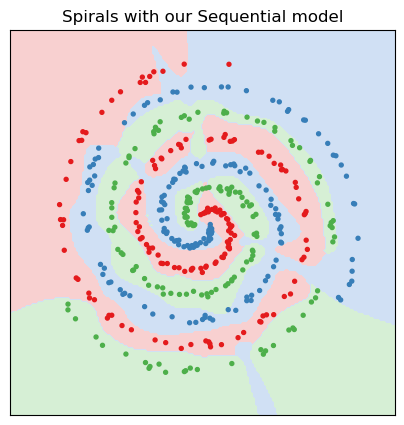

In [9]:
def make_spirals(n=150, turns=2, noise=0.15):
    X, y = [], []
    for k in range(3):
        r = np.linspace(0.05, 1, n)
        t = np.linspace(0, turns * 2 * np.pi, n) + k * 2 * np.pi / 3 + rng.normal(0, noise, n)
        X.append(np.c_[r * np.sin(t), r * np.cos(t)])
        y += [k] * n
    X, y = np.vstack(X), np.array(y)
    idx = rng.permutation(len(X))
    return X[idx], y[idx]

Xs, ys = make_spirals()
spiral_net = Sequential([Dense(2, 16, "xavier"), Tanh(), Dense(16, 16, "xavier"), Tanh(), Dense(16, 3, "xavier")])
spiral_net.compile(SoftmaxCrossEntropy(), Adam(0.01))
spiral_net.summary(2)
spiral_net.fit(Xs[90:], ys[90:], epochs=500, batch_size=16)
print(f"test accuracy: {spiral_net.evaluate(Xs[:90], ys[:90])[1]:.1f}%")

g = np.linspace(-1.2, 1.2, 200)
G1, G2 = np.meshgrid(g, g)
fig, ax = plt.subplots(figsize=(5, 5))
ax.contourf(G1, G2, spiral_net.predict(np.c_[G1.ravel(), G2.ravel()]).reshape(G1.shape), levels=[-0.5, 0.5, 1.5, 2.5],
            colors=["#f8d0d0", "#d0e0f4", "#d6efd5"])
ax.scatter(Xs[:, 0], Xs[:, 1], c=np.array(["#e41a1c", "#377eb8", "#4daf4a"])[ys], s=8)
ax.set(title="Spirals with our Sequential model", xticks=[], yticks=[], aspect="equal")
plt.show()

## 8c. MNIST (from the mini-batch notebook): 784 ➜ 128 ➜ dropout ➜ 64 ➜ 10, with early stopping

In [10]:
mnist = np.load(io.BytesIO(urllib.request.urlopen("https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz").read()))
Xm_tr, ym_tr = mnist["x_train"].reshape(-1, 784) / 255, mnist["y_train"]
Xm_te, ym_te = mnist["x_test"].reshape(-1, 784) / 255, mnist["y_test"]

mnist_net = Sequential([Dense(784, 128), ReLU(), Dropout(0.2), Dense(128, 64), ReLU(), Dense(64, 10)])
mnist_net.compile(SoftmaxCrossEntropy(), Adam(0.001))
mnist_net.summary(784)
start = time.time()
mnist_net.fit(Xm_tr[:54000], ym_tr[:54000], epochs=5, batch_size=64, validation_data=(Xm_tr[54000:], ym_tr[54000:]), patience=2)
print(f"test accuracy: {mnist_net.evaluate(Xm_te, ym_te)[1]:.2f}% | {time.time() - start:.0f} s")

layer                    output shape   weights
-----------------------------------------------
Dense                     (None, 128)    100480
ReLU                      (None, 128)         0
Dropout                   (None, 128)         0
Dense                      (None, 64)      8256
ReLU                       (None, 64)         0
Dense                      (None, 10)       650
-----------------------------------------------
total weights                            109386
Epoch    1 | loss 0.1446 | val loss 0.1267 | val accuracy 96.48
Epoch    2 | loss 0.0942 | val loss 0.0969 | val accuracy 97.33
Epoch    3 | loss 0.0642 | val loss 0.0741 | val accuracy 97.85
Epoch    4 | loss 0.0493 | val loss 0.0697 | val accuracy 97.83
Epoch    5 | loss 0.0475 | val loss 0.0694 | val accuracy 98.08
test accuracy: 97.53% | 14 s


## 8d. Regression: car fuel efficiency (from the loss-functions notebook), Huber loss, 1 linear output

In [11]:
raw = urllib.request.urlopen("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv").read().decode()
data = np.genfromtxt(io.StringIO(raw), delimiter=",", skip_header=1, usecols=(0, 1, 2, 3, 4, 5, 6))
data = data[~np.isnan(data).any(axis=1)]
y_mpg, X_mpg = data[:, 0], data[:, 1:]
order = rng.permutation(len(data))
te, tr = order[:80], order[80:]
X_mpg = (X_mpg - X_mpg[tr].mean(axis=0)) / X_mpg[tr].std(axis=0)

for loss in [MSE(), Huber()]:
    mpg_net = Sequential([Dense(6, 32), ReLU(), Dense(32, 1)])
    mpg_net.compile(loss, Adam(0.01))
    print(f"--- {type(loss).__name__} ---")
    mpg_net.fit(X_mpg[tr], y_mpg[tr], epochs=200, batch_size=16)
    print(f"test: average error {mpg_net.evaluate(X_mpg[te], y_mpg[te])[1]:.2f} mpg")

--- MSE ---
Epoch    1 | loss 371.3411
Epoch   20 | loss 8.3983
Epoch   40 | loss 7.0507
Epoch   60 | loss 7.2027
Epoch   80 | loss 7.5542
Epoch  100 | loss 6.6240
Epoch  120 | loss 5.9027
Epoch  140 | loss 5.6831
Epoch  160 | loss 5.4532
Epoch  180 | loss 5.1735
Epoch  200 | loss 5.0778
test: average error 1.94 mpg
--- Huber ---
Epoch    1 | loss 17.7454
Epoch   20 | loss 1.4502
Epoch   40 | loss 1.3469
Epoch   60 | loss 1.2814
Epoch   80 | loss 1.2872
Epoch  100 | loss 1.2157
Epoch  120 | loss 1.1917
Epoch  140 | loss 1.1830
Epoch  160 | loss 1.1748
Epoch  180 | loss 1.2304
Epoch  200 | loss 1.1371
test: average error 2.05 mpg


---
# Part 9: adding something new = one small class
**Leaky ReLU** (from the activations notebook) and **RMSProp** (from the optimisers notebook): nothing else changes.

In [12]:
class LeakyReLU(Layer):
    def __init__(self, slope=0.01):
        self.slope = slope
    def forward(self, X, training=False):
        self.S = X
        return np.where(X > 0, X, self.slope * X)
    def backward(self, grad):
        return grad * np.where(self.S > 0, 1.0, self.slope)

class RMSProp:
    def __init__(self, lr=0.001):
        self.lr, self.s = lr, {}
    def step(self, layers):
        for layer in layers:
            for p, g in layer.params_and_grads():
                s = self.s.setdefault(id(p), np.zeros_like(p))
                s[:] = 0.9 * s + 0.1 * g ** 2
                p -= self.lr * g / (np.sqrt(s) + 1e-8)

new_net = Sequential([Dense(2, 16), LeakyReLU(), Dense(16, 16), LeakyReLU(), Dense(16, 3)])
new_net.compile(SoftmaxCrossEntropy(), RMSProp(0.005))
gradient_check(new_net, Xs[:20], ys[:20], checks_per_layer=1)
new_net.fit(Xs[90:], ys[90:], epochs=500, batch_size=16)
print(f"spirals with LeakyReLU + RMSProp: test accuracy {new_net.evaluate(Xs[:90], ys[:90])[1]:.1f}%")

print("\nThe same model with Adam instead (one word changes):")
adam_net = Sequential([Dense(2, 16), LeakyReLU(), Dense(16, 16), LeakyReLU(), Dense(16, 3)])
adam_net.compile(SoftmaxCrossEntropy(), Adam(0.01))
adam_net.fit(Xs[90:], ys[90:], epochs=500, batch_size=16)
print(f"test accuracy {adam_net.evaluate(Xs[:90], ys[:90])[1]:.1f}%")

layer 0 (Dense) W[1,12]: backward -0.007106 | nudging -0.007106
layer 2 (Dense) W[3,14]: backward -0.000744 | nudging -0.000744
layer 4 (Dense) W[3,0]: backward +0.001616 | nudging +0.001616
Epoch    1 | loss 1.0782
Epoch   50 | loss 0.9245
Epoch  100 | loss 0.8387
Epoch  150 | loss 0.7062
Epoch  200 | loss 0.5842
Epoch  250 | loss 0.3775
Epoch  300 | loss 0.3948
Epoch  350 | loss 0.2436
Epoch  400 | loss 0.1928
Epoch  450 | loss 0.1591
Epoch  500 | loss 0.0887
spirals with LeakyReLU + RMSProp: test accuracy 94.4%

The same model with Adam instead (one word changes):
Epoch    1 | loss 1.0955
Epoch   50 | loss 0.7635
Epoch  100 | loss 0.4086
Epoch  150 | loss 0.2002
Epoch  200 | loss 0.0537
Epoch  250 | loss 0.0174
Epoch  300 | loss 0.0053
Epoch  350 | loss 0.0019
Epoch  400 | loss 0.0008
Epoch  450 | loss 0.0004
Epoch  500 | loss 0.0002
test accuracy 97.8%


## Modern activations as three more small classes: ELU, GELU, Swish
(Formulas and slopes: activation-functions notebook, Part 4.) Compared in a **deep** network: 6 hidden layers of 64, 10,000 MNIST images, Adam, 5 epochs, 2 random starts each.

In [13]:
import math
erf = np.vectorize(math.erf)

class ELU(Layer):
    def forward(self, X, training=False):
        self.S = X
        return np.where(X > 0, X, np.exp(X) - 1)
    def backward(self, grad):
        return grad * np.where(self.S > 0, 1.0, np.exp(self.S))

class GELU(Layer):
    def forward(self, X, training=False):
        self.S, self.Phi = X, 0.5 * (1 + erf(X / np.sqrt(2)))
        return X * self.Phi
    def backward(self, grad):
        return grad * (self.Phi + self.S * np.exp(-self.S ** 2 / 2) / np.sqrt(2 * np.pi))

class Swish(Layer):
    def forward(self, X, training=False):
        self.S, self.sig = X, 1 / (1 + np.exp(-X))
        return X * self.sig
    def backward(self, grad):
        return grad * (self.sig + self.S * self.sig * (1 - self.sig))

modern_check = Sequential([Dense(4, 6), ELU(), Dense(6, 6), GELU(), Dense(6, 6), Swish(), Dense(6, 3)])
modern_check.compile(SoftmaxCrossEntropy(), SGD())
gradient_check(modern_check, rng.normal(0, 1, (5, 4)), rng.integers(0, 3, 5), checks_per_layer=1)

layer 0 (Dense) W[2,0]: backward +0.137631 | nudging +0.137631
layer 2 (Dense) W[3,5]: backward +0.260586 | nudging +0.260586
layer 4 (Dense) W[5,0]: backward +0.006692 | nudging +0.006692
layer 6 (Dense) W[0,0]: backward -0.005601 | nudging -0.005601


In [14]:
import contextlib, io as io_module

def deep_net(activation):
    init = "xavier" if activation in (Tanh, Sigmoid) else "he"
    layers = [Dense(784, 64, init), activation()]
    for _ in range(5):
        layers += [Dense(64, 64, init), activation()]
    return Sequential(layers + [Dense(64, 10, init)])

print(f"{'activation':>10} | {'test accuracy (2 starts)':>24} | {'seconds':>7}")
print("-" * 50)
for activation in [ReLU, LeakyReLU, Tanh, ELU, GELU, Swish, Sigmoid]:
    accs, start = [], time.time()
    for _ in range(2):
        net = deep_net(activation)
        net.compile(SoftmaxCrossEntropy(), Adam(0.001))
        with contextlib.redirect_stdout(io_module.StringIO()):     # hide the epoch lines
            net.fit(Xm_tr[:10000], ym_tr[:10000], epochs=5, batch_size=64)
        accs.append(net.evaluate(Xm_te, ym_te)[1])
    print(f"{activation.__name__:>10} | {str(np.round(accs, 1)):>24} | {time.time() - start:7.0f}")

activation | test accuracy (2 starts) | seconds
--------------------------------------------------
      ReLU |              [94.  94.3] |       4
 LeakyReLU |              [94.1 93.9] |       4
      Tanh |              [92.6 93.1] |       4
       ELU |              [93.2 93.9] |       4
      GELU |              [94.2 94.8] |      15
     Swish |              [94.4 94. ] |       5
   Sigmoid |              [72.4 77.7] |       5


With good starting weights and Adam, ELU, GELU and Swish match or slightly beat ReLU here (differences under 1%), and sigmoid falls far behind in a deep network (vanishing gradients). GELU is slow in our NumPy version because of `erf`; frameworks compute it fast, which is why it is affordable in transformers.

---
# Part 10: our classes vs Keras vs PyTorch (next notebooks)

| Our class | Keras | PyTorch |
|---|---|---|
| `Dense(n_in, n_out)` | `layers.Dense(n_out)` | `nn.Linear(n_in, n_out)` |
| `ReLU()`, `Tanh()`, `Sigmoid()`, `LeakyReLU()`, `ELU()`, `GELU()`, `Swish()` | `activation="relu"` / `"elu"` / `"gelu"` / `"swish"` | `nn.ReLU()`, `nn.ELU()`, `nn.GELU()`, `nn.SiLU()`, … |
| `Dropout(p)` | `layers.Dropout(p)` | `nn.Dropout(p)` |
| `Dense(..., l2=λ)` | `kernel_regularizer=l2(λ)` | `weight_decay=λ` in the optimiser |
| `SoftmaxCrossEntropy()` | `loss="sparse_categorical_crossentropy"` | `nn.CrossEntropyLoss()` |
| `BinaryCrossEntropy()`, `MSE()`, `Huber()` | `"binary_crossentropy"`, `"mse"`, `"huber"` | `nn.BCEWithLogitsLoss()`, `nn.MSELoss()`, `nn.HuberLoss()` |
| `SGD`, `Momentum`, `RMSProp`, `Adam` | `optimizers.SGD`, `…(momentum=0.9)`, `RMSprop`, `Adam` | `optim.SGD`, `…(momentum=0.9)`, `optim.RMSprop`, `optim.Adam` |
| `Sequential([...])` | `keras.Sequential([...])` | `nn.Sequential(...)` |
| `compile` + `fit(..., patience=)` | `compile` + `fit(..., callbacks=[EarlyStopping])` | write the loop yourself |
| `backward()` (we wrote every slope) | automatic | `loss.backward()` (automatic) |
| `summary(n_inputs)` | `model.summary()` | `print(model)` |

The big difference: frameworks compute every slope **automatically** (and can use a GPU). That is the next notebook.